Train shape: (50000, 32, 32, 3) Test shape: (10000, 32, 32, 3)


/tmp/ipykernel_1311/1453135865.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


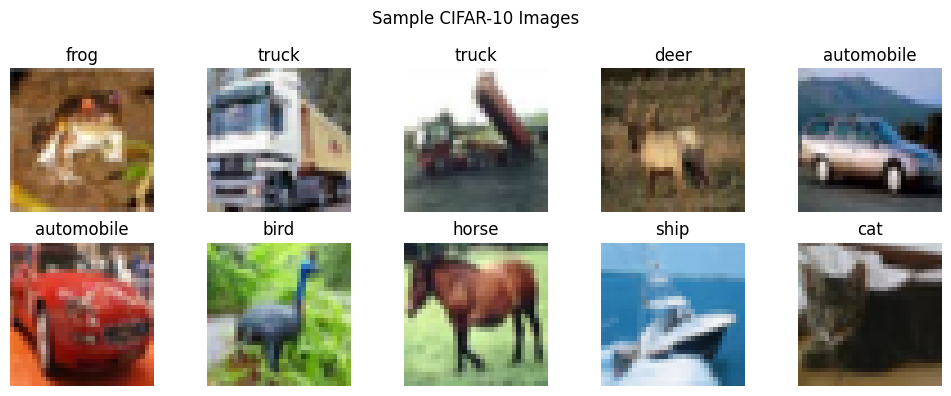

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.2964 - loss: 1.9548 - val_accuracy: 0.3294 - val_loss: 1.8580
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.3522 - loss: 1.7966 - val_accuracy: 0.3670 - val_loss: 1.7442
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.3784 - loss: 1.7330 - val_accuracy: 0.3914 - val_loss: 1.6906
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.3881 - loss: 1.6932 - val_accuracy: 0.3846 - val_loss: 1.6980
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.4071 - loss: 1.6553 - val_accuracy: 0.4016 - val_loss: 1.6550
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.4171 - loss: 1.6361 - val_accuracy: 0.4090 - val_loss: 1.6413
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.4220 - loss: 1.6174 - val_accuracy: 0.4264 - val_loss: 1.6148
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.4290 - loss: 1.5989 - 

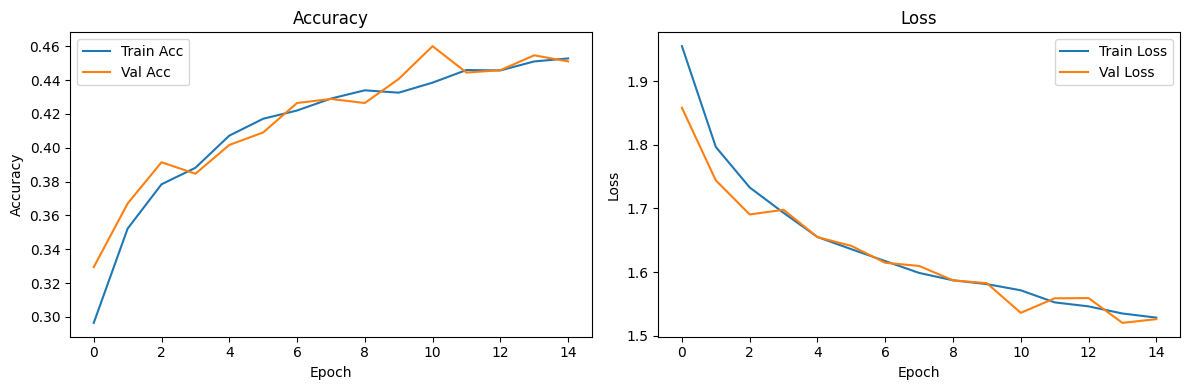

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test Accuracy: 0.4862
Test Precision (macro): 0.4935881172511629
Test Recall (macro): 0.4862
Test F1 (macro): 0.4738486053879791

Classification Report:
              precision    recall  f1-score   support

    airplane       0.61      0.43      0.51      1000
  automobile       0.56      0.69      0.62      1000
        bird       0.42      0.23      0.29      1000
         cat       0.36      0.26      0.30      1000
        deer       0.47      0.36      0.41      1000
         dog       0.42      0.40      0.41      1000
        frog       0.38      0.76      0.51      1000
       horse       0.64      0.46      0.54      1000
        ship       0.54      0.73      0.62      1000
       truck       0.53      0.55      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.47     10000
weighted avg       0.49      0.49      0.47     10000



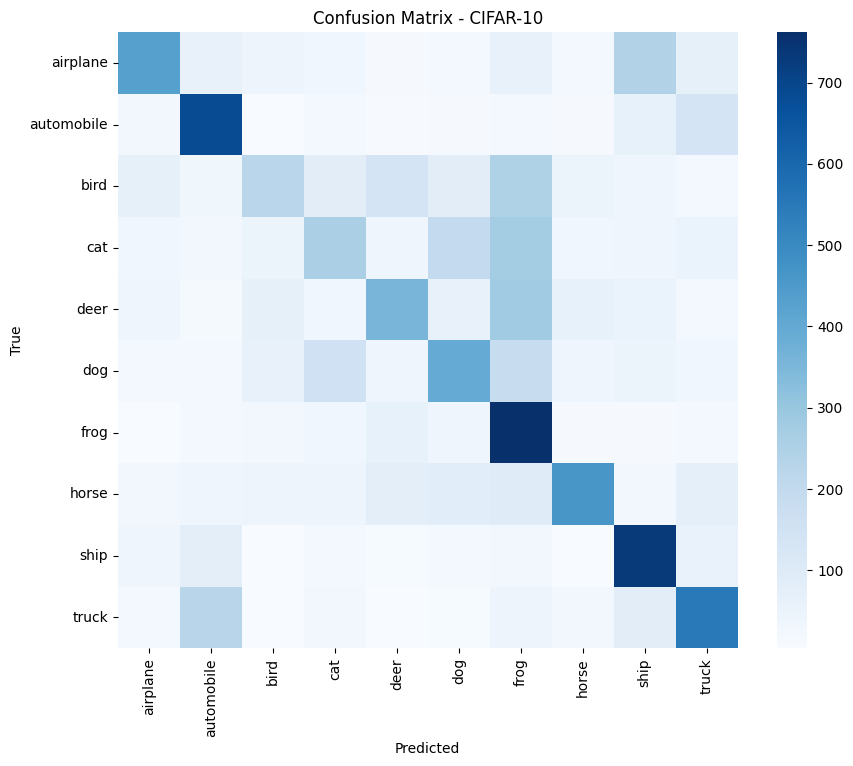

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


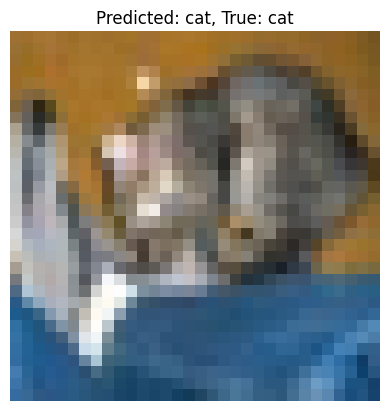

In [3]:
# =========================================================
# 1. SETUP: LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =========================================================
# 2. DATA LOADING: CIFAR-10
# =========================================================
# CIFAR-10: 60,000 32x32 color images, 10 classes
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

# =========================================================
# 3. VISUALIZE SAMPLE IMAGES
# =========================================================
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

# =========================================================
# 4. PREPROCESSING: NORMALIZATION + ONE-HOT ENCODING
# =========================================================
# Scale pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# =========================================================
# 5. OPTIONAL: DATA AUGMENTATION
# =========================================================
augment = True  # set False if you want to disable

if augment:
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        validation_split=0.1  # use part of training as validation
    )
    datagen.fit(x_train)
else:
    datagen = ImageDataGenerator(validation_split=0.1)
    datagen.fit(x_train)

batch_size = 64
train_gen = datagen.flow(
    x_train, y_train_cat,
    batch_size=batch_size,
    subset="training"
)
val_gen = datagen.flow(
    x_train, y_train_cat,
    batch_size=batch_size,
    subset="validation"
)

# =========================================================
# 6. MODEL: SIMPLE FEEDFORWARD (ON FLATTENED IMAGES)
#    (Not CNN on purpose, to keep architecture simple)
# =========================================================
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

# =========================================================
# 7. COMPILE MODEL
# =========================================================
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================================================
# 8. TRAINING
# =========================================================
epochs = 15

history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen
)

# =========================================================
# 9. TRAINING CURVES (LOSS & ACCURACY)
# =========================================================
def plot_history(history):
    # Accuracy
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# =========================================================
# 10. EVALUATION ON TEST SET
# =========================================================
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("Test Precision (macro):", precision_score(y_true, y_pred, average="macro"))
print("Test Recall (macro):", recall_score(y_true, y_pred, average="macro"))
print("Test F1 (macro):", f1_score(y_true, y_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CIFAR-10")
plt.show()

# =========================================================
# 11. SIMPLE EXPERIMENTS (EASY TO MODIFY)
# =========================================================
# You can try:
# - More layers
# - Different units (e.g., 512, 256, 128)
# - Different optimizer: "sgd", "rmsprop"
# - Turn augment = False and compare metrics

# Example: a slightly deeper model (just as a template)
def build_deeper_model():
    m = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    m.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return m

# =========================================================
# 12. PRACTICAL PREDICTION FUNCTION
# =========================================================
def predict_single_image(model, img_array):
    """
    img_array: single image, shape (32, 32, 3), values 0-255 or 0-1
    """
    if img_array.max() > 1.0:
        img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # (1, 32, 32, 3)
    probs = model.predict(img_array)
    pred_class = np.argmax(probs, axis=1)[0]
    return pred_class, class_names[pred_class]

# Test on one test image
idx = 0
test_img = x_test[idx]
pred_idx, pred_name = predict_single_image(model, test_img)
plt.imshow(test_img)
plt.title(f"Predicted: {pred_name}, True: {class_names[y_true[idx]]}")
plt.axis("off")
plt.show()